In [1]:
### identify cluster marker genes
suppressPackageStartupMessages({
    library(Seurat)
    library(stringr)
    library(dplyr)
    library(patchwork)
    library(ggplot2)
    library(future)
    library(tidydr)
    library(harmony)
    library(reticulate)
    library(viridis)
    library(RColorBrewer)
    library(ComplexHeatmap)
    library(colorRamp2)
    library(edgeR)
})

# set large memory  
options(future.globals.maxSize = 120*1024^3)

## plotting parameters
umap_theme <- theme_dr()+theme(panel.grid.major = element_blank(), 
                                            panel.grid.minor = element_blank(),
                                            panel.background = element_blank(), 
                                            axis.line = element_line(colour = "black"))

## set working dir
dir = "/home/kibr/Work/Vascular_atlas"
setwd(dir)

In [2]:
h5ad_file="./Results/Revision_2/clean_object_revision_04242026.h5ad"
clean = schard::h5ad2seurat(h5ad_file)
print(clean)

The value -2^31 was detected in the dataset.
This has been converted to NA within R.

The value -2^31 was detected in the dataset.
This has been converted to NA within R.

Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from Xumap.decontx_ to Xumapdecontx_”
Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from Xumap.harmony_ to Xumapharmony_”
Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from Xumap.harmony.denoised_ to Xumapharmonydenoised_”
Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from Xumap.rna_ to Xumaprna_”


An object of class Seurat 
36782 features across 443443 samples within 1 assay 
Active assay: RNA (36782 features, 0 variable features)
 2 layers present: counts, data
 8 dimensional reductions calculated: Xharmony_, Xpca_, Xpcaharmony_, Xumap.decontx_, Xumap.harmony_, Xumap.harmony.denoised_, Xumap.rna_, umapharmony_


## based on the input genes related to stroke gwas, try to plot the expression of these genes each brain regions among different cell types.

In [3]:
## Only focus on the genes of interest
genes_oi <- c(
  # Chr 1
  "PRDM16", "CASZ1", "INPP5B", "WNT2B", "IL6R", "PMF1", "ATP1B1", "PRRX1", "LAMC1",
  # Chr 2
  "KCNK3", "THADA", "USP34", "FIGN", "NBEAL1", "FN1",
  # Chr 3
  "FGD5", "DAZL", "PLSCR5",
  # Chr 4
  "NOA1", "FGF5", "PITX2", "PCDH18", "EDNRA", "FBN2", "FGG", "F11",
  # Chr 5
  "TRIM36", "LOC100505841", "CENPQ", "ARHGAP26", "LPA",
  # Chr 6
  "FOXF2", "TAP1", "SLC22A7",
  # Chr 7
  "HDAC9", "EVX1", "COBL", "CDK6", "PIK3CG", "THAP5", "PTK2", "NOS3",
  # Chr 8
  "DEFB1", "EBF2",
  # Chr 9
  "BNC2", "CDKN2B-AS1", "PTCH1", "SHOC1", "ABO",
  # Chr 10
  "JCAD", "LIPA", "SH3PXD2A", "RBM20", "GRK5", "HTRA1",
  # Chr 11
  "LSP1", "TMEM41B", "SWAP70", "OVOL1", "MMP12",
  # Chr 12
  "PDE3A", "ANKRD33", "HOXC4", "TSPAN19", "ATP2B1", "SH2B3", "PTPN11", "NCOR2",
  # Chr 13
  "FLT1", "LRCH1", "COL4A2",
  # Chr 14
  "HHIPL1",
  # Chr 15
  "MESDC1", "FURIN", "LINC00924",
  # Chr 16
  "ZFHX3", "CDH13", "ZCCHC14",
  # Chr 17
  "POLR2A", "DRC3", "RPRML", "MTMR4",
  # Chr 18
  "RMC1", "DYM",
  # Chr 19
  "SLC44A2", "LDLR",
  # Chr 20
  "PROCR"
)

length(genes_oi) 

[1] 87

In [4]:
genes_exclude = c("PITX2","ANKRD33","DEFB1")
## for fibroblast, need to remove more genes
genes_exclude = c(genes_exclude, "MMP12")

genes_oi = genes_oi[!genes_oi %in% genes_exclude]

length(genes_oi)

[1] 83

In [5]:
table(clean$Cell_class)


             Astrocyte            Endothelial         Ependymal_Cell 
                 25829                  45554                   4039 
       Epithelial_Cell             Fibroblast Microglia_Macrophage_T 
                  6543                  27185                  12249 
            Mural_Cell                 Neuron        Oligodendrocyte 
                120279                   7616                 164319 
                   OPC 
                 29830 

In [6]:
table(clean$region_layer)


            Barrier           Brainstem          Cerebellum              Cortex 
              10175               19931                2520              203421 
             Limbic        Major Vessel           Olfactory           Watershed 
              28183              111708                2671               41423 
White Matter Tracts 
              23411 

In [16]:
## organizing the brain region information into three categories: cortex, major vessles, and others
## add a new column "Region_group" to the metadata of the clean object
clean$Region_group = ifelse(clean$region_layer %in% c("Cortex"), "Cortex",
                            ifelse(clean$region_layer %in% c("Major Vessel"), "Major_Vessel",
                                ifelse(clean$region_layer %in% c("Watershed"), "Watershed", "Other_regions")))
table(clean$Region_group)


       Cortex  Major_Vessel Other_regions     Watershed 
       203421        111708         86891         41423 

### Joint heatmap: GWAS genes x (Endothelial + Mural + Fibroblast) × Region Groups

In [8]:
# genes_oi = genes_oi[genes_oi %in% rownames(logCPM)]
genes_exclude = c("PITX2","ANKRD33","DEFB1")
## for fibroblast, need to remove more genes
genes_exclude = c(genes_exclude, "MMP12")

genes_oi = genes_oi[!genes_oi %in% genes_exclude]

In [ ]:
# ### Joint heatmap: GWAS genes x (Endothelial + Mural + Fibroblast) × Region Groups
# # ── Helper: compute logCPM_region_group_z for one Seurat object ──────────────
# get_region_z <- function(obj, cell_type_label) {
#   DefaultAssay(obj) <- "RNA"
  
#   mtx <- AggregateExpression(
#     obj,
#     group.by = c("region_name", "individualID"),
#     assays   = "RNA",
#     slot     = "counts"
#   )
#   mtx <- as.matrix(mtx$RNA)
  
#   lib_size <- Matrix::colSums(mtx)
#   cpm      <- t(t(mtx) / lib_size) * 1e6
#   logCPM   <- log2(cpm + 1)
  
#   # Filter to GWAS genes present in this object
#   genes_use <- genes_oi[genes_oi %in% rownames(logCPM)]
#   logCPM    <- logCPM[genes_use, , drop = FALSE]
  
#   # Map sample → region_group
#   region <- sapply(colnames(logCPM), function(x) str_split(x, "_")[[1]][1])
#   meta   <- obj@meta.data
#   rg_meta <- unique(meta[, c("region_name", "region_layer", "Region_group")])
#   ID           <- match(region, rg_meta$region_name)
#   region_group <- rg_meta$Region_group[ID]
  
#   # Average per region_group
#   logCPM_rg <- sapply(
#     split(seq_len(ncol(logCPM)), region_group),
#     function(i) rowMeans(logCPM[, i, drop = FALSE])
#   )
  
#   # Z-score across region groups (per gene)
#   logCPM_rg_z <- t(scale(t(logCPM_rg)))
  
#   # Rename columns:  "Cortex" → "Endo_Cortex"  etc.
#   colnames(logCPM_rg_z) <- paste(cell_type_label, colnames(logCPM_rg_z), sep = "_")
  
#   return(logCPM_rg_z)
# }



# mat_endo  <- pad_missing(mat_endo,  all_genes)
# mat_mural <- pad_missing(mat_mural, all_genes)
# mat_fibro <- pad_missing(mat_fibro, all_genes)

# # ── 3. Column-bind into one joint matrix ─────────────────────────────────────
# joint_mat <- cbind(mat_endo, mat_mural, mat_fibro)

In [17]:
# ── 3. Column-bind into one joint matrix ─────────────────────────────────────
# First cbind the RAW logCPM (not z-scored) matrices, then z-score jointly
# Modify get_region_z to return logCPM_rg instead of z-scored version
get_region_logCPM <- function(obj, cell_type_label) {
  DefaultAssay(obj) <- "RNA"
  mtx <- AggregateExpression(obj, group.by = c("region_name", "individualID"),
                              assays = "RNA", slot = "counts")
  mtx <- as.matrix(mtx$RNA)
  lib_size <- Matrix::colSums(mtx)
  cpm      <- t(t(mtx) / lib_size) * 1e6
  logCPM   <- log2(cpm + 1)
  
  genes_use <- genes_oi[genes_oi %in% rownames(logCPM)]
  logCPM    <- logCPM[genes_use, , drop = FALSE]
  
  region  <- sapply(colnames(logCPM), function(x) str_split(x, "_")[[1]][1])
  meta    <- obj@meta.data
  rg_meta <- unique(meta[, c("region_name", "region_layer", "Region_group")])
  ID           <- match(region, rg_meta$region_name)
  region_group <- rg_meta$Region_group[ID]
  
  logCPM_rg <- sapply(
    split(seq_len(ncol(logCPM)), region_group),
    function(i) rowMeans(logCPM[, i, drop = FALSE])
  )
  
  # Return raw logCPM (NOT z-scored yet)
  colnames(logCPM_rg) <- paste(cell_type_label, colnames(logCPM_rg), sep = "_")
  return(logCPM_rg)
}

obj_endo = subset(clean, subset = Cell_class == "Endothelial")
obj_mural = subset(clean, subset = Cell_class == "Mural_Cell")
obj_fibro = subset(clean, subset = Cell_class == "Fibroblast")
# # ── 1. Compute per-cell-type matrices ────────────────────────────────────────
# Replace obj_endo / obj_mural / obj_fibro with your actual Seurat objects
mat_endo  <- get_region_logCPM(obj_endo,  "Endothelial")
mat_mural <- get_region_logCPM(obj_mural, "Mural_Cell")
mat_fibro <- get_region_logCPM(obj_fibro, "Fibroblast")

# # ── 2. Union of GWAS genes across all three matrices ─────────────────────────
# all_genes <- union(union(rownames(mat_endo), rownames(mat_mural)), rownames(mat_fibro))

pad_missing <- function(mat, all_genes) {
  missing <- setdiff(all_genes, rownames(mat))
  if (length(missing) > 0) {
    pad <- matrix(NA, nrow = length(missing), ncol = ncol(mat),
                  dimnames = list(missing, colnames(mat)))
    mat <- rbind(mat, pad)
  }
  mat[all_genes, , drop = FALSE]
}

# ── Define desired region order ───────────────────────────────────────────────
region_order <- c("Cortex", "Major_Vessel", "Watershed", "Other_regions")

# Reorder columns within each matrix after get_region_logCPM
reorder_cols <- function(mat, cell_type_label) {
  desired <- paste(cell_type_label, region_order, sep = "_")
  # Only keep columns that actually exist in the data
  desired <- desired[desired %in% colnames(mat)]
  mat[, desired, drop = FALSE]
}

mat_endo  <- reorder_cols(mat_endo,  "Endothelial")
mat_mural <- reorder_cols(mat_mural, "Mural_Cell")
mat_fibro <- reorder_cols(mat_fibro, "Fibroblast")

# Pad missing genes AFTER reordering
all_genes <- union(union(rownames(mat_endo), rownames(mat_mural)), rownames(mat_fibro))
mat_endo  <- pad_missing(mat_endo,  all_genes)
mat_mural <- pad_missing(mat_mural, all_genes)
mat_fibro <- pad_missing(mat_fibro, all_genes)

# Combine and z-score jointly
joint_mat_raw <- cbind(mat_endo, mat_mural, mat_fibro)
joint_mat     <- t(scale(t(joint_mat_raw)))

Warning message:
“`offset` is deprecated, use `location` instead.”
'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



agg_record_1160773153 
                    2

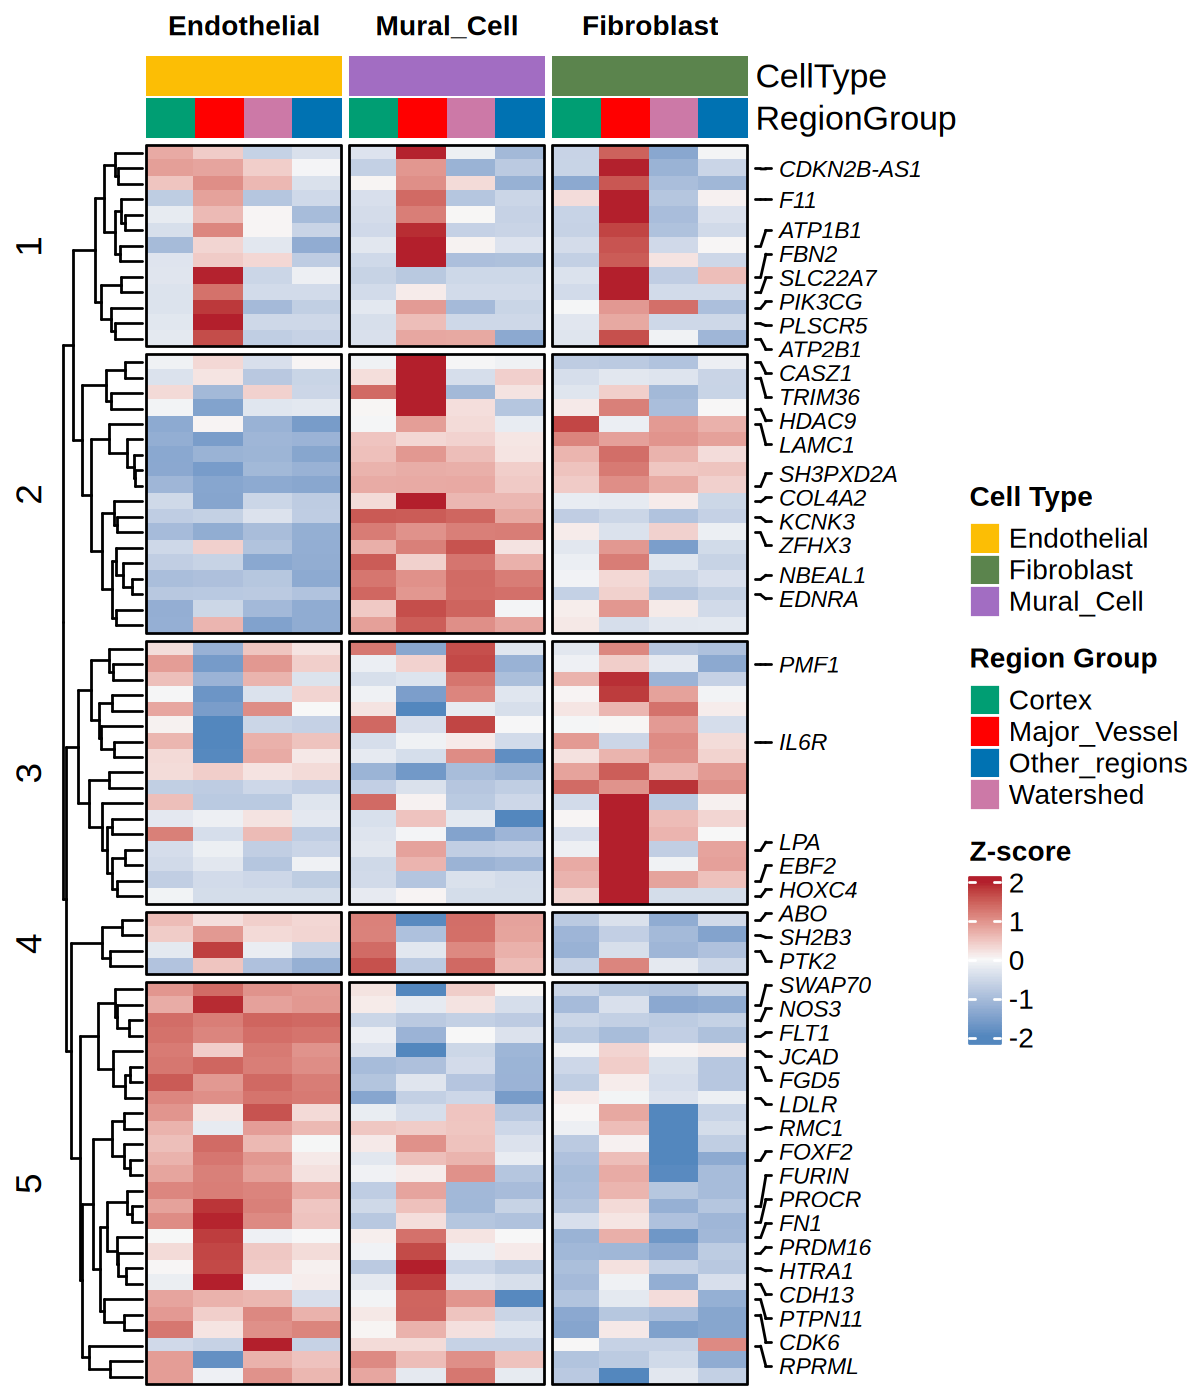

In [43]:
# ── 4. Build top annotations ─────────────────────────────────────────────────
# Cell-type annotation
cell_type_vec <- c(
  rep("Endothelial", ncol(mat_endo)),
  rep("Mural_Cell",       ncol(mat_mural)),
  rep("Fibroblast",  ncol(mat_fibro))
)

cell_type_colors <- c(
  Endothelial = "#fcbe05",
  Mural_Cell  = "#A26DC2",
  Fibroblast  = "#5b844d"
)

# Region-group annotation (strip cell-type prefix to recover original label)
region_group_vec <- c(
  sub("^Endothelial_", "", colnames(mat_endo)),
  sub("^Mural_Cell_",  "", colnames(mat_mural)),
  sub("^Fibroblast_",  "", colnames(mat_fibro))
)

region_colors <- c(
  Cortex                    = "#009E73",
  Major_Vessel              = "#FF0000",
  Watershed = "#CC79A7",
  Other_regions             = "#0072B2"
)

top_anno <- HeatmapAnnotation(
  CellType    = cell_type_vec,
  RegionGroup = region_group_vec,
  col = list(
    CellType    = cell_type_colors,
    RegionGroup = region_colors
  ),
  annotation_name_side = "right",
  annotation_legend_param = list(
    CellType    = list(title = "Cell Type"),
    RegionGroup = list(title = "Region Group")
  )
)

# Bottom annotation: rotated column labels
bot_anno <- HeatmapAnnotation(
  text = anno_text(
    colnames(joint_mat),
    rot    = 90,
    offset = unit(1, "npc"),
    just   = "right"
  ),
  annotation_height = max_text_width(colnames(joint_mat))
)

# ── 5. Select representative / label genes ───────────────────────────────────
# Keep only genes with a strong signal in at least one column
gene_max_z <- apply(joint_mat, 1, function(x) max(abs(x), na.rm = TRUE))

# Label the top N genes OR a hand-picked list
top_n        <- 10
label_genes  <- names(sort(gene_max_z, decreasing = TRUE))[1:top_n]

# Optionally, add any manually curated genes you always want labelled:
label_genes <- union(label_genes, c(
  "CDKN2B-AS1", "ATP2B1", "ATP1B1", "F11", "FBN2", "PIK3CG",
  "COL4A2", "HTRA1", "EDNRA", "SH3PXD2A", "LAMC1", "NBEAL1",
  "FOXF2", "NOS3", "PRDM16",
  "FURIN", "PMF1", "ABO", "LPA", "CDK6", "SH2B3", "PTK2",
  "HDAC9", "FN1", "PTPN11", "SWAP70", "PLSCR5", "IL6R",
  "ZFHX3", "FLT1", "JCAD", "FGD5", "LDLR", "PROCR",
  "CDH13", "KCNK3", "SLC22A7"
))

# Build row labels: show gene name only for selected genes, blank otherwise
# row_labels <- ifelse(rownames(joint_mat) %in% label_genes,
#                      rownames(joint_mat), "")
# Indices in the ORIGINAL matrix (this is what anno_mark needs)
highlight_idx <- which(rownames(joint_mat) %in% label_genes)

# Build the right-side mark annotation
right_anno <- rowAnnotation(
  mark = anno_mark(
    at        = highlight_idx,
    labels    = rownames(joint_mat)[highlight_idx],
    which     = "row",
    side      = "right",
    labels_gp = gpar(fontsize = 8, fontface = "italic", col = "black"),
    link_width = unit(3, "mm"),     # length of the connector segment
    padding   = unit(1, "mm"),       # gap between labels
    extend    = unit(5, "mm")        # allow labels to extend past heatmap edge
  )
)
# ── 6. Column splits (one block per cell type) ───────────────────────────────
col_split <- factor(cell_type_vec, levels = c("Endothelial", "Mural_Cell", "Fibroblast"))

# ── 7. Draw heatmap ──────────────────────────────────────────────────────────
ht_joint <- Heatmap(
  joint_mat,
  name             = "Z-score",
  col              = colorRamp2(c(-2, 0, 2), c("#5387be", "#F7F7F7", "#b31f2c")),
  
  # Rows
  cluster_rows     = TRUE,
  show_row_names   = FALSE,
  row_split        = 5,
  # row_labels       = row_labels,
  row_names_gp     = gpar(fontsize = 7),
  
  # Columns
  cluster_columns  = FALSE,          # keep cell-type blocks together
  column_split     = col_split,
  column_title_gp  = gpar(fontsize = 10, fontface = "bold"),
  show_column_names = FALSE,
  
  # Annotations
  top_annotation   = top_anno,
  right_annotation = right_anno,
  # bottom_annotation = bot_anno,
  
  # Misc
  na_col           = "grey90",
  use_raster       = TRUE,
  border           = TRUE
)

# ── 8. Save ──────────────────────────────────────────────────────────────────
pdf("./Results/Revision_2/Figures/Figure_5X_Stroke_genes_Joint_Heatmap.pdf",
    width = 6, height = 7)
draw(ht_joint, merge_legend = TRUE)
dev.off()

options(repr.plot.width = 6, repr.plot.height = 7, repr.plot.res = 200)
draw(ht_joint, merge_legend = TRUE)